# Atividade 7 – Meio de transporte das mulheres ocupadas, por cor ou raça (IBGE, Censo 2022)

## PARTE 1

In [2]:


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Leitura da aba *Exemplo gráfico Brasil*

In [3]:
arquivo = 'Tabela_13_Meio_de_transporte.xlsx'

# a linha 0 é o título da tabela, o cabeçalho está na linha 1
df = pd.read_excel(arquivo, sheet_name='Exemplo gráfico Brasil', header=1)

# padroniza os nomes das colunas para bater com o código do gráfico
df.columns = ['Meio de Transporte', 'Branca', 'Preta ou Parda', 'Indígena']
df

,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


### Gráficos de pizza

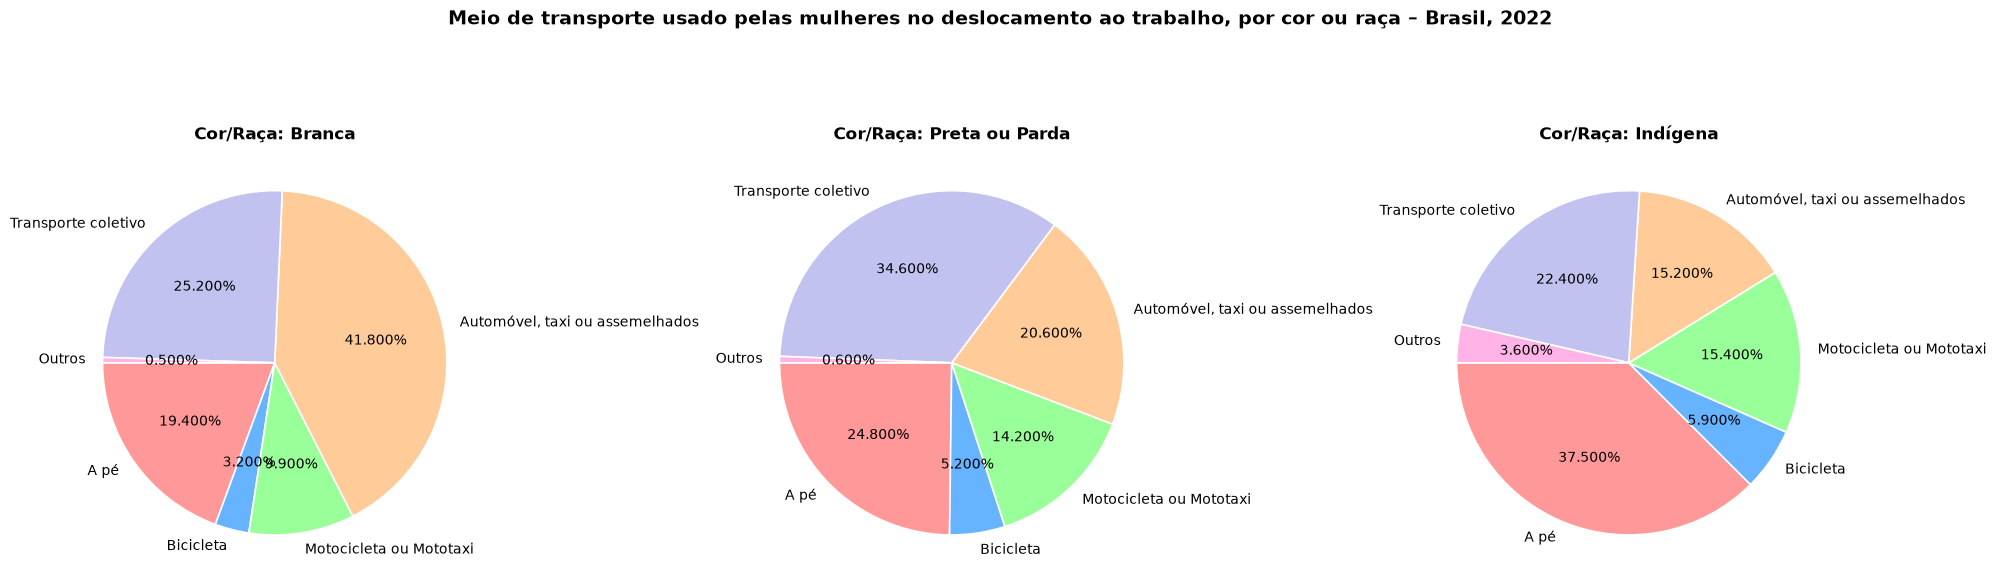

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',   
        startangle=180,      
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meio de transporte usado pelas mulheres no deslocamento ao trabalho, por cor ou raça – Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

### Diferenças entre os grupos (em pontos percentuais)

In [5]:
dif = df.set_index('Meio de Transporte')
dif = pd.DataFrame({
    'Branca - Preta ou Parda':   dif['Branca'] - dif['Preta ou Parda'],
    'Branca - Indígena':         dif['Branca'] - dif['Indígena'],
    'Preta ou Parda - Indígena': dif['Preta ou Parda'] - dif['Indígena'],
}).round(1)
dif

,Branca - Preta ou Parda,Branca - Indígena,Preta ou Parda - Indígena
Meio de Transporte,,,
A pé,-5.4,-18.1,-12.7
Bicicleta,-2.0,-2.7,-0.7
Motocicleta ou Mototaxi,-4.3,-5.5,-1.2
"Automóvel, taxi ou assemelhados",21.2,26.6,5.4
Transporte coletivo,-9.4,2.8,12.2
Outros,-0.1,-3.1,-3.0


### Análise dos gráficos

As diferenças abaixo estão em **pontos percentuais (p.p.)**. Valor positivo = o primeiro grupo usa mais aquele meio.

**A pé**
- Mulheres brancas − mulheres pretas ou pardas: **−5,4 p.p.** (19,4% vs 24,8%)
- Mulheres brancas − mulheres indígenas: **−18,1 p.p.** (19,4% vs 37,5%)
- Mulheres pretas ou pardas − mulheres indígenas: **−12,7 p.p.** (24,8% vs 37,5%)

**Bicicleta**
- Brancas − pretas ou pardas: **−2,0 p.p.** (3,2% vs 5,2%)
- Brancas − indígenas: **−2,7 p.p.** (3,2% vs 5,9%)
- Pretas ou pardas − indígenas: **−0,7 p.p.** (5,2% vs 5,9%)

**Motocicleta ou mototáxi**
- Brancas − pretas ou pardas: **−4,3 p.p.** (9,9% vs 14,2%)
- Brancas − indígenas: **−5,5 p.p.** (9,9% vs 15,4%)
- Pretas ou pardas − indígenas: **−1,2 p.p.** (14,2% vs 15,4%)

**Carro (automóvel, táxi ou assemelhados)**
- Brancas − pretas ou pardas: **+21,2 p.p.** (41,8% vs 20,6%)
- Brancas − indígenas: **+26,6 p.p.** (41,8% vs 15,2%)
- Pretas ou pardas − indígenas: **+5,4 p.p.** (20,6% vs 15,2%)

**Transporte coletivo**
- Brancas − pretas ou pardas: **−9,4 p.p.** (25,2% vs 34,6%)
- Brancas − indígenas: **+2,8 p.p.** (25,2% vs 22,4%)
- Pretas ou pardas − indígenas: **+12,2 p.p.** (34,6% vs 22,4%)

**Outros**
- Brancas − pretas ou pardas: **−0,1 p.p.** (0,5% vs 0,6%)
- Brancas − indígenas: **−3,1 p.p.** (0,5% vs 3,6%)
- Pretas ou pardas − indígenas: **−3,0 p.p.** (0,6% vs 3,6%)

**Conclusão:** o carro é o principal meio das mulheres brancas (41,8%), com uma vantagem de mais de 20 p.p. sobre os outros grupos. Entre as mulheres pretas ou pardas, o principal meio é o transporte coletivo (34,6%), e entre as indígenas é andar a pé (37,5%). Os meios mais baratos (a pé, bicicleta e moto) crescem à medida que se passa de brancas para pretas/pardas e para indígenas, o que indica desigualdade de acesso ao transporte individual motorizado.

## PARTE 2

### Leitura da aba *BR GR UF MU*

In [13]:
racas = ['Branca', 'Preta ou Parda', 'Indígena']
meios = ['A pé', 'Bicicleta', 'Motocicleta ou Mototaxi',
         'Automóvel, taxi ou assemelhados', 'Transporte coletivo', 'Outros']

df2 = pd.read_excel(arquivo, sheet_name='BR GR UF MU', header=None,
                    skiprows=3, na_values='.')
df2.columns = ['Local'] + [f'{r}|{m}' for r in racas for m in meios]
df2['Local'] = df2['Local'].astype(str).str.strip()
df2.head(10)

,Local,Branca|A pé,Branca|Bicicleta,Branca|Motocicleta ou Mototaxi,"Branca|Automóvel, taxi ou assemelhados",Branca|Transporte coletivo,Branca|Outros,Preta ou Parda|A pé,Preta ou Parda|Bicicleta,Preta ou Parda|Motocicleta ou Mototaxi,"Preta ou Parda|Automóvel, taxi ou assemelhados",Preta ou Parda|Transporte coletivo,Preta ou Parda|Outros,Indígena|A pé,Indígena|Bicicleta,Indígena|Motocicleta ou Mototaxi,"Indígena|Automóvel, taxi ou assemelhados",Indígena|Transporte coletivo,Indígena|Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26.0,0.6,42.0,4.2,19.4,13.1,20.6,0.7
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23.0,4.5,7.0,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
4,Sul,20.8,3.5,7.3,48.0,20.0,0.5,24.0,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1.0
5,Centro-oeste,12.3,4.9,15.0,49.0,18.2,0.4,16.1,7.7,18.3,29.4,28.0,0.4,24.5,16.2,17.5,18.3,22.9,0.7
6,Rondônia,11.7,7.2,36.7,39.3,4.5,0.6,14.8,12.8,39.9,25.5,6.6,0.4,36.3,17.8,29.9,13.4,1.9,0.6
7,Acre,14.8,8.9,27.0,39.4,9.2,0.6,20.0,13.0,29.5,24.7,11.6,1.2,56.7,1.9,16.5,11.4,6.8,6.7
8,Amazonas,13.9,2.0,14.3,37.2,30.1,2.5,20.9,2.5,20.4,18.9,33.3,4.0,49.0,3.6,17.5,6.3,8.7,14.9
9,Roraima,11.6,5.8,20.2,54.3,7.3,0.8,14.6,7.9,25.9,40.6,9.8,1.2,38.6,6.6,25.4,20.6,7.3,1.4


### Listando apenas os estados
Os municípios terminam com a sigla da UF entre parênteses, ex.: `Brasília (DF)`. Brasil e as Grandes Regiões ficam de fora.

In [14]:
regioes = ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste']
eh_municipio = df2['Local'].str.contains(r'\(\w{2}\)$')

estados = df2[~eh_municipio & ~df2['Local'].isin(regioes)].copy()
municipios = df2[eh_municipio].copy()

print(len(estados), 'estados |', len(municipios), 'municípios')
estados['Local'].tolist()

27 estados | 5570 municípios


['Rondônia',
 'Acre',
 'Amazonas',
 'Roraima',
 'Pará',
 'Amapá',
 'Tocantins',
 'Maranhão',
 'Piauí',
 'Ceará',
 'Rio Grande do Norte',
 'Paraíba',
 'Pernambuco',
 'Alagoas',
 'Sergipe',
 'Bahia',
 'Minas Gerais',
 'Espírito Santo',
 'Rio de Janeiro',
 'São Paulo',
 'Paraná',
 'Santa Catarina',
 'Rio Grande do Sul',
 'Mato Grosso do Sul',
 'Mato Grosso',
 'Goiás',
 'Distrito Federal']

### Transformando para formato longo com `melt`

In [15]:
def para_longo(tabela):
    longo = tabela.melt(id_vars='Local', var_name='Grupo', value_name='Percentual')
    longo[['Raça', 'Meio']] = longo['Grupo'].str.split('|', expand=True)
    return longo.drop(columns='Grupo')

estados_longo = para_longo(estados)
municipios_longo = para_longo(municipios)
estados_longo.head()

,Local,Percentual,Raça,Meio
0,Rondônia,11.7,Branca,A pé
1,Acre,14.8,Branca,A pé
2,Amazonas,13.9,Branca,A pé
3,Roraima,11.6,Branca,A pé
4,Pará,17.5,Branca,A pé


### Transporte coletivo por estado (`groupby`)
Como a tabela traz percentuais por cor ou raça, "mulheres em geral" foi calculado como a **média dos percentuais das três raças** em cada estado.

In [16]:
coletivo_uf = (estados_longo[estados_longo['Meio'] == 'Transporte coletivo']
               .groupby('Local')['Percentual']
               .mean()
               .sort_values(ascending=False))

print('Estado com MAIS mulheres no transporte coletivo:',
      coletivo_uf.idxmax(), f'({coletivo_uf.max():.2f}%)')
print('Estado com MENOS mulheres no transporte coletivo:',
      coletivo_uf.idxmin(), f'({coletivo_uf.min():.2f}%)')
coletivo_uf.round(2)

Estado com MAIS mulheres no transporte coletivo: Rio de Janeiro (52.23%)
Estado com MENOS mulheres no transporte coletivo: Rondônia (4.33%)


Local
Rio de Janeiro         52.23
Distrito Federal       46.00
São Paulo              40.73
Rio Grande do Sul      36.10
Sergipe                33.40
Espírito Santo         32.63
Paraná                 27.57
Minas Gerais           27.10
Goiás                  25.10
Pernambuco             25.03
Amazonas               24.03
Santa Catarina         23.77
Rio Grande do Norte    23.73
Ceará                  23.40
Bahia                  23.10
Alagoas                22.37
Pará                   20.63
Paraíba                19.70
Maranhão               17.23
Mato Grosso do Sul     16.60
Amapá                  15.30
Piauí                  15.07
Mato Grosso             9.80
Acre                    9.20
Tocantins               8.60
Roraima                 8.13
Rondônia                4.33
Name: Percentual, dtype: float64

### Bicicleta e carro por município
Mesma lógica (média das três raças). Foram considerados só os municípios **com dado para as três raças**, porque em muitos municípios pequenos só há uma ou duas raças com dado, às vezes com 100% baseado em pouquíssimas pessoas, o que distorceria o ranking.

In [17]:
def ranking_municipios(meio):
    return (municipios_longo[municipios_longo['Meio'] == meio]
            .groupby('Local')['Percentual']
            .agg(['mean', 'count'])
            .query('count == 3')           
            .sort_values('mean', ascending=False)['mean'])

bike = ranking_municipios('Bicicleta')
carro = ranking_municipios('Automóvel, taxi ou assemelhados')

print('Cidade com mais mulheres de bicicleta:', bike.idxmax(), f'({bike.max():.2f}%)')
print('Cidade com mais mulheres de carro:', carro.idxmax(), f'({carro.max():.2f}%)')

Cidade com mais mulheres de bicicleta: Lagoa Grande (MG) (67.87%)
Cidade com mais mulheres de carro: Bom Jesus (SC) (74.57%)


In [18]:
bike.head(5).round(2)

Local
Lagoa Grande (MG)              67.87
Britânia (GO)                  64.47
Bom Jesus do Tocantins (TO)    64.37
Tumiritinga (MG)               63.87
Cocalinho (MT)                 59.27
Name: mean, dtype: float64

In [19]:
carro.head(5).round(2)

Local
Bom Jesus (SC)         74.57
Valinhos (SP)          71.43
Piratininga (SP)       71.40
Nova Odessa (SP)       68.57
Pinheiro Preto (SC)    68.43
Name: mean, dtype: float64

### Respostas

1. **Estado com mais mulheres, em geral, usando transporte coletivo:** **Rio de Janeiro**, com média de 52,23% (Branca 44,5%, Preta ou Parda 57,8%, Indígena 54,4%).
2. **Estado com menos mulheres, em geral, usando transporte coletivo:** **Rondônia**, com média de 4,33%.
3. **Cidade do Brasil com mais mulheres andando de bicicleta:** **Lagoa Grande (MG)**, com média de 67,87%.
4. **Cidade do Brasil com mais mulheres utilizando carro:** **Bom Jesus (SC)**, com média de 74,57%.
